## Imports

In [136]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
import joblib

# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier
#from xgboost import XGBClassifier



## Config

In [137]:
URGENCY_MAP = {"منخفض": 1, "متوسط": 2, "عاجل": 3}

AVAILABILITY_MAP = {
    "اليوم": 3,
    "غدا": 2,
    "خلال أسبوع": 1
}


## Load & Sample Data

In [138]:
# Load data
requests_df = pd.read_csv("../requests.csv")
donors_df = pd.read_csv("../donors.csv")

# Take sample
req_sample = requests_df.sample(5000, random_state=42)
don_sample = donors_df.sample(5000, random_state=42)

print("Requests sample:", req_sample.shape)
print("Donors sample:", don_sample.shape)

Requests sample: (5000, 8)
Donors sample: (5000, 6)


## Generate Request–Donor Pairs (Cross Join)

In [139]:
pairs = []

for _, req in req_sample.iterrows():
    sampled_donors = don_sample.sample(50, replace=False)

    for _, donor in sampled_donors.iterrows():
        row = {}

        # request
        row.update(req.to_dict())

        # donor
        row["donation_type"] = donor["donation_type"]
        row["available_quantity"] = donor["available_quantity"]
        row["location_donor"] = donor["location_donor"]
        row["availability"] = donor["availability"]
        row["Trust_Score"] = donor["Trust_Score"]

        pairs.append(row)

pairs = pd.DataFrame(pairs)

print("Total pairs:", len(pairs))
pairs.head()

Total pairs: 250000


,request_id,need_type,needed_quantity,location_requester,urgency,age,family_members,is_family,donation_type,available_quantity,location_donor,availability,Trust_Score
0,1502,علاج,10,بورسعيد,متوسط,37,5,1,علاج,14,بورسعيد,خلال أسبوع,45
1,1502,علاج,10,بورسعيد,متوسط,37,5,1,علاج,7,الجيزة,خلال أسبوع,41
2,1502,علاج,10,بورسعيد,متوسط,37,5,1,علاج,4,طنطا,اليوم,59
3,1502,علاج,10,بورسعيد,متوسط,37,5,1,علاج,11,الإسكندرية,اليوم,58
4,1502,علاج,10,بورسعيد,متوسط,37,5,1,أكل,5,الأقصر,اليوم,90


## GPS

In [140]:
from geopy.geocoders import Nominatim
from geopy.distance import geodesic

geolocator = Nominatim(user_agent="matching_app")

location_cache = {}

def get_coordinates(location_name):
    if location_name in location_cache:
        return location_cache[location_name]

    try:
        location = geolocator.geocode(location_name)

        if location:
            coords = (location.latitude, location.longitude)
            location_cache[location_name] = coords
            return coords
    except:
        return None

    return None

def compute_distance_km(loc1_name, loc2_name):
    try:
        loc1 = get_coordinates(loc1_name + ", Egypt")
        loc2 = get_coordinates(loc2_name + ", Egypt")

        if loc1 is None or loc2 is None:
            return 1000  # fallback آمن

        return geodesic(loc1, loc2).km

    except:
        return 1000

## Feature Engineering

In [141]:
# 1. Matching features
pairs["need_match"] = (pairs["need_type"] == pairs["donation_type"]).astype(int)

pairs["location_match"] = (pairs["location_requester"] == pairs["location_donor"]).astype(int)

pairs["same_location"] = (pairs["location_requester"] == pairs["location_donor"]).astype(int)

# 2. Scores
pairs["urgency_score"] = pairs["urgency"].map(URGENCY_MAP)
pairs["availability_score"] = pairs["availability"].map(AVAILABILITY_MAP)

# 3. Quantity fit (continuous better than binary)
pairs["quantity_fit"] = (pairs["available_quantity"] / pairs["needed_quantity"]).clip(upper=1)
pairs["quantity_fit"] = np.sqrt(pairs["quantity_fit"])

# 4. Trust
pairs["trust_score"] = pairs["Trust_Score"] / 100

# 5. Distance
pairs["distance_km"] = pairs.apply(
    lambda row: compute_distance_km(
        row["location_requester"],
        row["location_donor"]
    ),
    axis=1
)
pairs["distance_score"] = 1 / (1 + (pairs["distance_km"] / 50))
pairs = pairs.sample(frac=1).reset_index(drop=True)

In [142]:
FEATURE_COLS = [
    "need_match",
    "location_match",
    "urgency_score",
    "availability_score",
    "quantity_fit",
    "distance_score"
]

## Label Generation (Rule-based + Noise)

In [143]:
score = (
    pairs["need_match"] * 1.5+
    pairs["location_match"] *  2.5+
    pairs["distance_score"] * 3 + 
    pairs["urgency_score"] * 2 +
    pairs["availability_score"] * 1.5 +
    pairs["quantity_fit"] * 1.5
)
noise = np.random.normal(0,0.5, len(pairs))
pairs["final_score"] = score + noise
# نحول لـ label
threshold = pairs["final_score"].quantile(0.6)
pairs["label"] = (pairs["final_score"] > threshold).astype(int)

print(pairs["final_score"].describe())

count    250000.000000
mean         10.181709
std           2.780049
min           3.039809
25%           8.197608
50%           9.978777
75%          11.938933
max          20.538878
Name: final_score, dtype: float64


## Train/Test

In [144]:
X = pairs[FEATURE_COLS]
y = pairs["final_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (200000, 6)
Test size: (50000, 6)


## Train Models

XGBoost (Final Model)

In [145]:
model = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train, verbose=True)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Model Evaluation 

In [146]:
from sklearn.metrics import mean_squared_error

preds = model.predict(X_test)
mse = mean_squared_error(y_test, preds)

print(f"MSE: {mse:.4f}")

MSE: 0.2528


In [147]:
joblib.dump(model, "model.pkl")


['model.pkl']

In [148]:
# # Predictions
# y_pred = xgb_model.predict(X_test)
# y_proba = xgb_model.predict_proba(X_test)[:, 1]
# # Metrics
# accuracy = accuracy_score(y_test, y_pred)
# auc = roc_auc_score(y_test, y_proba)

# # Classification report as table
# report = classification_report(y_test, y_pred, output_dict=True)
# report_df = pd.DataFrame(report).transpose()


# report_df = report_df.loc[["0", "1"]]
# report_df = report_df.round(2)
# accuracy_df = pd.DataFrame({
#     "Model": ["XGBoost"],
#     "Accuracy": [accuracy],
#     "AUC": [auc]
# })

# print("Model Performance Summary")
# display(accuracy_df.style.format({"Accuracy": "{:.2%}", "AUC": "{:.3f}"}))
# display(report_df)

## Priority-Based Matching Function

In [149]:
def match_requests_priority(model, requests_df, donor_row, k=3):
    candidates = requests_df.copy()

    # 1. Matching
    candidates["need_match"] = (candidates["need_type"] == donor_row["donation_type"]).astype(int)

    # 2. Scores
    candidates["urgency_score"] = candidates["urgency"].map(URGENCY_MAP)
    candidates["availability_score"] = AVAILABILITY_MAP[donor_row["availability"]]

    # 3. Quantity
    candidates["quantity_fit"] = (
    donor_row["available_quantity"] / candidates["needed_quantity"]
    ).clip(upper=1)

    candidates["quantity_fit"] = np.sqrt(candidates["quantity_fit"])

    # location_match
    candidates["location_match"] = (
        candidates["location_requester"] == donor_row["location"]
    ).astype(int)

    # distance
    candidates["distance_km"] = candidates["location_requester"].apply(
        lambda loc: compute_distance_km(loc, donor_row["location"])
    )

    candidates["distance_score"] = 1 / (1 + (candidates["distance_km"] / 50))
    
    # Prediction
    X = candidates[FEATURE_COLS]
    candidates["predicted_score"] = model.predict(X)

    if donor_row["availability"] == "خلال أسبوع":
        candidates.loc[candidates["urgency"] == "عاجل", "predicted_score"] -= 3
        candidates.loc[candidates["urgency"] == "متوسط", "predicted_score"] -= 2

    elif donor_row["availability"] == "غدًا":
        candidates.loc[candidates["urgency"] == "عاجل", "predicted_score"] -= 2
    
    # لو "اليوم" → مفيش خصم خالص
    # Ranking
    candidates["final_score"] = ( candidates["predicted_score"]
)
    
    candidates = candidates.sort_values(
        by="final_score",
        ascending=False
    )

    return candidates.head(k)[[
        "need_type",
        "urgency",
        "location_requester",
        "predicted_score"

    ]].to_dict(orient="records")


## Test on New Data

In [154]:
donor_test = {
    "donation_type": "أكل",
    "available_quantity": 15,
    "availability": "اليوم",
    "location": "الجيزه"
}

test_requests = pd.DataFrame([
    {"need_type": "أكل", "needed_quantity": 5, "location_requester": "القاهرة", "urgency": "عاجل"},
    {"need_type": "أكل", "needed_quantity": 1, "location_requester": "الجيزة", "urgency": "متوسط"},
    {"need_type": "أكل", "needed_quantity": 10, "location_requester": "أسيوط", "urgency": "متوسط"},
])
results = match_requests_priority(model, test_requests, donor_test)
results = pd.DataFrame(results)

if results.empty:
    print("No suitable matches found for this donor.")
    
else: display(
    results.reindex(columns=[
        "need_type",
        "urgency",
        "location_requester",
        "predicted_score",
              
    ]).style.format({
        "predicted_score": "{:.2f}",
        "final_score": "{:.2f}"
    })
)           
    

,need_type,urgency,location_requester,predicted_score
0,أكل,عاجل,القاهرة,14.02
1,أكل,متوسط,الجيزة,12.01
2,أكل,متوسط,أسيوط,11.78


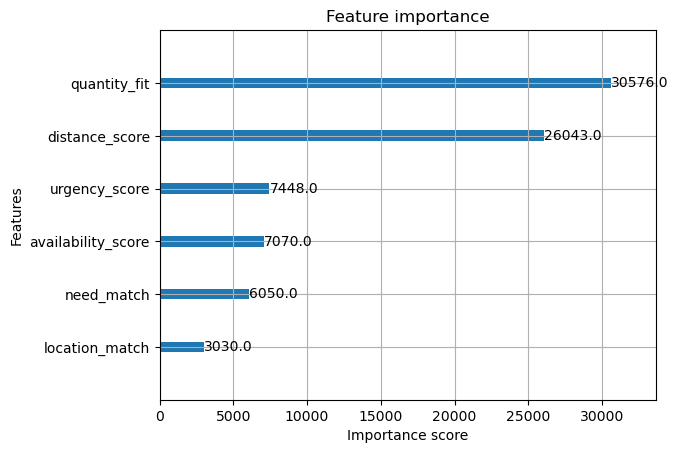

In [151]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(model)
plt.show()